In [1]:
from google.colab import files
import zipfile

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('unzipped_folder')

print("Extracted Successfully")

Saving archive(2).zip to archive(2).zip
Extracted Successfully


In [2]:
import os

print(os.listdir('unzipped_folder'))

['database.sqlite', 'Iris.csv']


In [3]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X = iris.data
y = iris.target

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
y_pred = knn.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [10]:
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"K={k}, Accuracy={score}")

K=1, Accuracy=0.9666666666666667
K=2, Accuracy=1.0
K=3, Accuracy=1.0
K=4, Accuracy=1.0
K=5, Accuracy=1.0
K=6, Accuracy=1.0
K=7, Accuracy=1.0
K=8, Accuracy=1.0
K=9, Accuracy=1.0
K=10, Accuracy=1.0


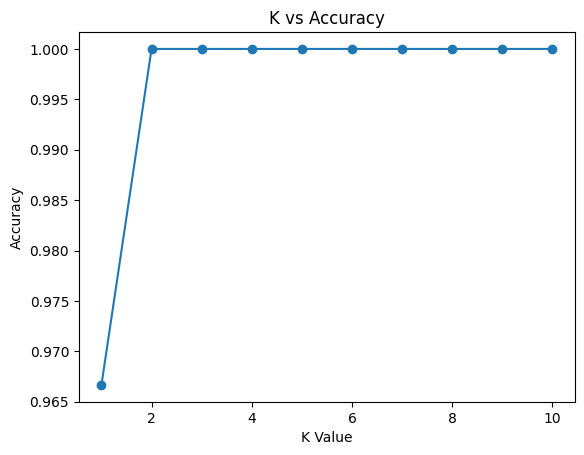

In [11]:
import matplotlib.pyplot as plt

k_values = range(1,11)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(model.score(X_test, y_test))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()